<a id='k9'></a>

# Kapitel 5 - Functions - Wie man Code recyclet

In diesem Kapitel werden wir das Recyclen von Rohstoffen betrachten und dabei etwas über Functions in Python lernen.

Nehmen wir an es gibt einen Produktionsprozess, der einen gewissen Rohstoff benötigt. Diesen Rohstoff kann man in einer Reinheit von 90% käuflich erwerben. Nach dem Produktionsprozess kann man den Rohstoff wiedergewinnen und theoretisch weiterbenutzen, er verliert aber ein Viertel seiner Reinheit. Mathematisch können wir das so ausdrücken:

In [1]:
reinheit = 0.9
reinheit_neu = reinheit * 0.75
print(reinheit_neu)

0.675


Der Rohstoff hat nun also nur mehr eine Reinheit von 67.5%. Wenn wir ihn so weiter verwenden, würde er sehr schnell eine Reinheit haben, mit der der Prozess nicht mehr funktioniert. Was aber, wenn wir ihn mit neuem Rohstoff mischen?

In [4]:
reinheit = 0.9
reinheit_rec = reinheit * 0.75

reinheit_neu = 0.5 * (reinheit + reinheit_rec) #Mittelwert
print(reinheit_neu)

0.7875000000000001


Nun hätten wir eine Reinheit von über 78% nach dem ersten Wiederverwenden. Interessant wäre nun herauszufinden, was passiert, wenn wir diese Schritte immer weiter wiederholen, also den Rohstoff immer wieder verwenden und neu mischen. Wie schnell fällt die Reinheit ab? Erreicht sie irgendwann 0?

Um das herauszufinden, können wir eine Liste und eine For-Schleife verwenden:

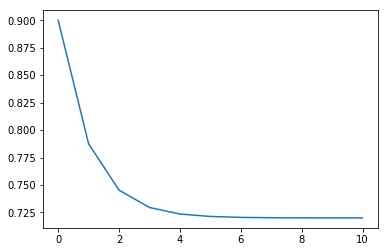

In [10]:
import matplotlib.pyplot as plt
%matplotlib inline

reinheit = 0.9
reinheit_liste = [reinheit] #eine Liste mit einem Eintrag wird erstellt

for it in range(10):
    reinheit = 0.5 * (0.9 + reinheit * 0.75)
    reinheit_liste.append(reinheit)
    

plt.plot(reinheit_liste)
plt.show()

Es sieht so aus, also würde die Reinheit nie unter einen gewissen Wert fallen. Scheinbar bildet sich ein Gleichgewicht aus. Egal wie oft wir den Prozess wiederholen, wir kommen nicht unter 70 Prozent. Hat das etwas damit zu tun, dass der Prozess die Reinheit um 25% reduziert? Was hätte ein anderer Parameterwert für eine Auswirkung? Das könnten wir einfach überprüfen, indem wir einfach den Parameter von ändern, zum Beispiel auf 0.8:

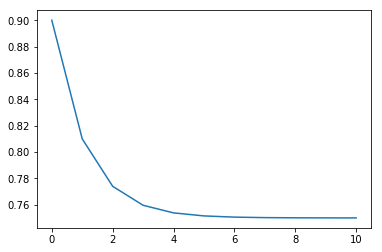

In [12]:
import matplotlib.pyplot as plt
%matplotlib inline

reinheit = 0.9
reinheit_liste = [reinheit]

for it in range(10):
    reinheit = 0.5 * (0.9 + reinheit * 0.8)
    reinheit_liste.append(reinheit)
    

plt.plot(reinheit_liste)
plt.show()

Tatsächlich ändert sich der Fixpunkt. Wir wollen nun mehrere Parameterwerte in einem Plot vergleichen. Die einfachste Lösung wäre, die Forschleife oft zu kopieren und den Parameter jedes mal zu ändern. Wir könnten das Programm auch in eine For-Schleife legen, aber das Ändern des Parameters wird dadurch sehr umständlich. Glücklichweise gibt es eine bessere Lösung: Wir benutzen **Functions**.

### Functions
Functions (nicht zu verwechseln mit mathematischen Funktionen) sind Programmierstrukturen, die kompliziertere Prozesse automatisch ausführen. Ähnlich wie mathematische Funktionen können sie einen Input und einen Output haben. Wir können ihnen einen Namen geben und sie somit platzsparend und übersichtlich aufrufen.

Functions sind immer dann empfehlenswert, wenn man einen Prozess an unterschiedlichen Stellen im Code braucht. Functions werden in Python mit dem Wort **def** deklariert. Man schreibt `def namederfunction():`, die Function selbst wird dann eingerückt. Bauen wir nun unsere Recycling-Prozess in eine Function um.

In [13]:
import matplotlib.pyplot as plt
%matplotlib inline


#eine eigene Function wird definiert:
def recyceln():
    reinheit = 0.9
    reinheit_liste = [reinheit]

    for it in range(10):
        reinheit = 0.5 * (0.9 + reinheit * 0.8)
        reinheit_liste.append(reinheit)


    plt.plot(reinheit_liste)
    

Man beachte: Nur durch das Definieren der Function wird sie noch nicht ausgeführt. Dazu müssen wir sie dezidiert aufrufen. Das macht man mit dem Namen der Funktion gefolgt von runden Klammern:

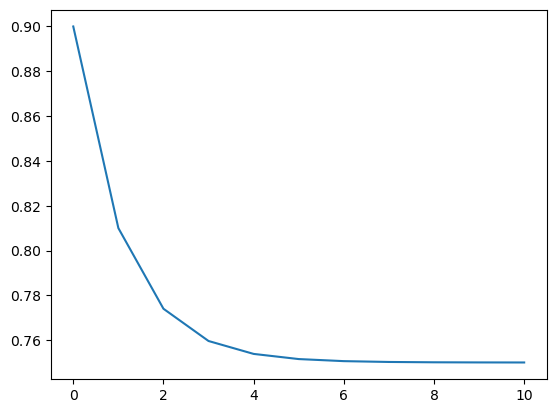

In [13]:
import matplotlib.pyplot as plt
%matplotlib inline

def recyceln():
    reinheit = 0.9
    reinheit_liste = [reinheit]

    for it in range(10):
        reinheit = 0.5 * (0.9 + reinheit * 0.8)
        reinheit_liste.append(reinheit)


    plt.plot(reinheit_liste)
    plt.show()

recyceln()


Was haben wir durch diese Function nun eigentlich gewonnen? Eine wichtige Eigenschaft von Functions ist, dass sie einen Inputwert haben können. Momentan verwendet unsere Function immer einen Parameter von 0.8, um zu berechnen wie viel Reinheit pro Schritt verloren wird. Diesen Parameter können wir umschreiben, sodass er als Inputparameter verwendet wird. Inputparameter werden wie folgt eingebaut:

Bei der **Definition** der Function kommt der **Name** des Parameters in die runde Klammer. Dieser Name kann dann innerhalb der Funktionsdefiniton benutzt werden.

Wenn die Function dann **aufgerufen** wird, gibt man den **Wert** den der Parameter haben soll, an.

Für unsere Recyclingfunction würde das also so aussehen:

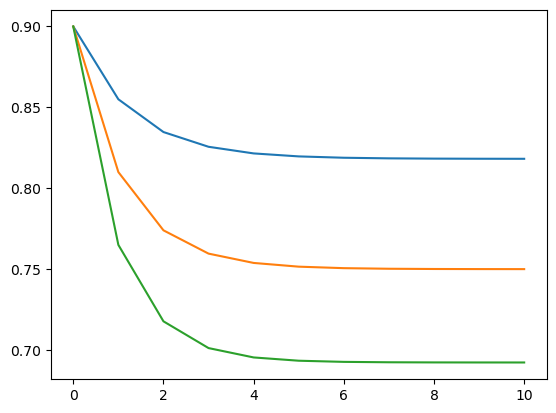

In [15]:
import matplotlib.pyplot as plt
%matplotlib inline

def recyceln(verlustparameter):
    reinheit = 0.9
    reinheit_liste = [reinheit]

    for it in range(10):
        reinheit = 0.5 * (0.9 + reinheit * verlustparameter)
        reinheit_liste.append(reinheit)


    plt.plot(reinheit_liste)

recyceln(0.9)
recyceln(0.8)
recyceln(0.7)
plt.show()

Somit können wir sehr elegant verschiedene Verlustparameter miteinander vergleichen. Im Plot wäre es aber schön, wenn wir die Linien beschriften würden, damit wir wissen, welche Linie zu welchem Parameterwert gehört. Functions können wir einfach anpassen: Wenn wir in der Definition etwas ändern, ist diese Änderung für alle Aufrufe gültig.

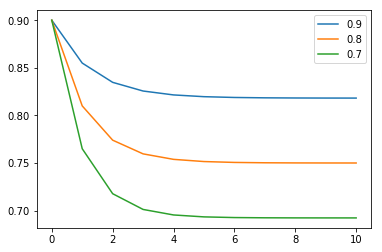

In [20]:
import matplotlib.pyplot as plt
%matplotlib inline

def recyceln(verlustparameter):
    reinheit = 0.9
    reinheit_liste = [reinheit]

    for it in range(10):
        reinheit = 0.5 * (0.9 + reinheit * verlustparameter)
        reinheit_liste.append(reinheit)


    plt.plot(reinheit_liste, label = verlustparameter) #wir fügen eine Beschriftung hinzu
    plt.legend() #die Beschriftungen sollen in einer Legende angezeigt werden

recyceln(0.9)
recyceln(0.8)
recyceln(0.7)
plt.show()

Functions können wir auch beliebig ausbauen. Wir können zum Beispiel einen zweiten Inputparameter einbauen. Weitere Inputparameter werden einfach mit Beistrichen getrennt. Bauen wir nun auch den Parameter, der uns sagt wir rein die frische Resource ist, als Parameter ein.

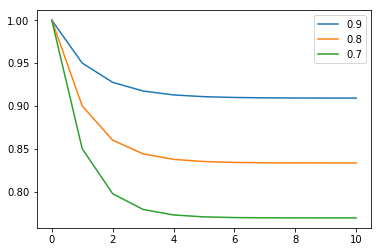

In [24]:
import matplotlib.pyplot as plt
%matplotlib inline

def recyceln(verlustparameter, startreinheit):
    reinheit = startreinheit
    reinheit_liste = [reinheit]

    for it in range(10):
        reinheit = 0.5 * (startreinheit + reinheit * verlustparameter)
        reinheit_liste.append(reinheit)


    plt.plot(reinheit_liste, label = verlustparameter)
    plt.legend()

recyceln(0.9,1.0)
recyceln(0.8,1.0)
recyceln(0.7,1.0)
plt.show()

Zusätzlich zum Inputwert kann eine Function auch einen Outputwert haben. Das ist sozusagen das Ergebnis der Function, also das, was die Function an das Hauptprogramm zurückgeben soll. In unserem Fall wäre das zum Beispiel der letzte Reinheitswert unserer Zeitreihe. Der Outputwert wird mit dem Wort **return** am Ende der Definition festgelegt. Immer wenn wir eine weitere Function (zum Beispiel `print`) auf eine andere Function anwenden, wenden wir sie eigentlich auf den Outputwert an.

0.9091218642081055
0.8333508096
0.7692371351092773


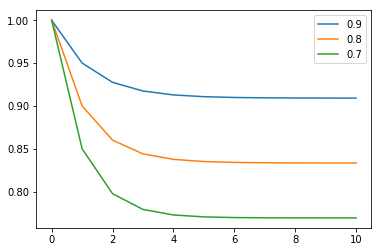

In [26]:
import matplotlib.pyplot as plt
%matplotlib inline

def recyceln(verlustparameter, startreinheit):
    reinheit = startreinheit
    reinheit_liste = [reinheit]

    for it in range(10):
        reinheit = 0.5 * (startreinheit + reinheit * verlustparameter)
        reinheit_liste.append(reinheit)


    plt.plot(reinheit_liste, label = verlustparameter)
    plt.legend()
    
    return reinheit_liste[-1] #das Element -1 einer Liste ist das letzte Element der Liste, egal wie lang die Liste ist

print(recyceln(0.9,1.0))
print(recyceln(0.8,1.0))
print(recyceln(0.7,1.0))
plt.show()

Darüber hinaus ist es möglich Functions innerhalb von Functions zu verwenden. Wir können das Zusammenmischen der Rohstoffe in eine eigene Function auslagern:

0.9091218642081055
0.8333508096
0.7692371351092773


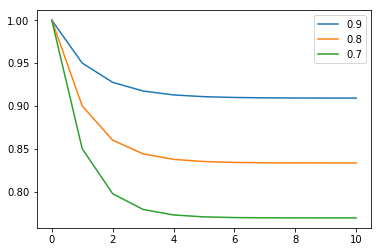

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline

def mischen(aktuell,start,verlust):
    neu = 0.5 * (start + aktuell * verlust)
    return neu


def recyceln(verlustparameter, startreinheit):
    reinheit = startreinheit
    reinheit_liste = [reinheit]

    for it in range(10):
        reinheit = mischen(reinheit,startreinheit,verlustparameter)
        reinheit_liste.append(reinheit)


    plt.plot(reinheit_liste, label = verlustparameter)
    plt.legend()
    
    return reinheit_liste[-1]

print(recyceln(0.9,1.0))
print(recyceln(0.8,1.0))
print(recyceln(0.7,1.0))
plt.show()

Analysieren wir nun einen anderen Recycle-Prozess. Wir produzieren Glasflaschen, die dann genutzt werden. Während der Nutzung lagern sich im Glas insgesamt 10 Milligram an Schadstoffen ab. Die Flaschen werden eingeschmolzen und neue Flaschen daraus gemacht. Dabei werden 15% der Schadstoffe entfernt. Wie lange dauert es, bis mehr als 50 Milligram in einer Flasche sind?

Versuchen wir dieses Problem mit Functions zu lösen. Schreiben wir zuerst eine Function, die den Verschmutzungsprozess beschreibt, und eine Function, die den Einschmelzprozess beschreibt.

Dann können wir diese Prozesse in eine For-Schleife geben und plotten was passiert.

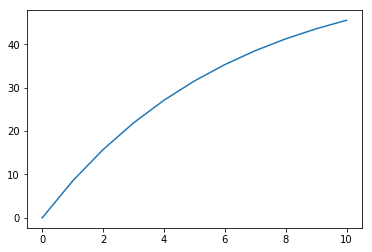

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

def verschmutzen(startwert):
    return startwert + 10

def schmelzen(startwert):
    return startwert * 0.85

schadstoff = 0
schadstoff_liste = [schadstoff]

for it in range(10):
    schadstoff = verschmutzen(schadstoff)
    schadstoff = schmelzen(schadstoff)
    schadstoff_liste.append(schadstoff)
    
plt.plot(schadstoff_liste)
plt.show()


Wenn wir die Funktionen verschachteln wird es deutlich kompakter. Die Functions werden von innen nach außen abgearbeitet:

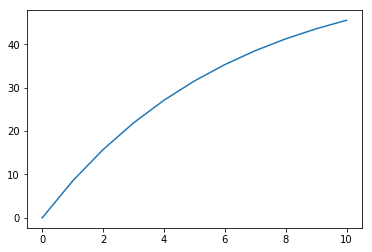

In [7]:
import matplotlib.pyplot as plt
%matplotlib inline

def verschmutzen(startwert):
    return startwert + 10

def schmelzen(startwert):
    return startwert * 0.85

schadstoff = 0
schadstoff_liste = [schadstoff]

for it in range(10):   
    schadstoff = schmelzen(verschmutzen(schadstoff))
    schadstoff_liste.append(schadstoff)
    
plt.plot(schadstoff_liste)
plt.show()

Wir sehen also: nach 10 Schritten ist der Grenzwert noch nicht überschritten. Wie können wir nun aber herausfinden, wann genau dieser Wert das erste mal überschritten wird? Wir könnten einfach die For-Schleife länger laufen lassen und so lange herumprobieren, bis wir einen geeigneten Wert finden. Es gibt aber eine bessere Lösung: Immer, wenn wir nicht wissen wie oft eine Schleife durchlaufen werden soll, sondern nur unter **welcher Bedingung sie abgebrochen werden sollte** (in unserem Fall beim Erreichen von 50 mg Schadstoff) kann man eine **While-Schleife** verwenden.

### Die While-Schleife

Bei der While-Schleife geben wir keine Anzahl an Schleifendurchgängen vor, sondern eine Bedingung. So lange diese Bedinung noch erfüllt ist wird die Schleife weiterlaufen. Man benutzt While-Schleifen mit

`while bedingung:
   anweisungen` 

Für unser Beispiel also:

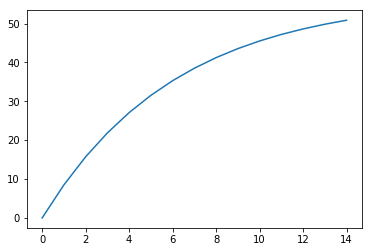

In [10]:
import matplotlib.pyplot as plt
%matplotlib inline

def verschmutzen(startwert):
    return startwert + 10

def schmelzen(startwert):
    return startwert * 0.85

schadstoff = 0
schadstoff_liste = [schadstoff]

while schadstoff < 50:   
    schadstoff = schmelzen(verschmutzen(schadstoff))
    schadstoff_liste.append(schadstoff)
    
plt.plot(schadstoff_liste)
plt.show()

While-Schleifen haben keine integrierte Variable, die mitzählt, wie oft die Schleife durchlaufen worden ist. Wenn wir so etwas brauchen (wie hier um die Anzahl der Wiederverwendungen zu finden) können wir das aber sehr einfach einbauen:

Nach
14
Prozessen ist der Schadstoffgrenzwert überschritten.


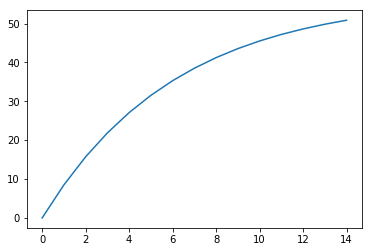

In [5]:
import matplotlib.pyplot as plt
%matplotlib inline

def verschmutzen(startwert):
    return startwert + 10

def schmelzen(startwert):
    return startwert * 0.85

schadstoff = 0
schadstoff_liste = [schadstoff]
counter = 0

while schadstoff < 50:   
    schadstoff = schmelzen(verschmutzen(schadstoff))
    schadstoff_liste.append(schadstoff)
    counter = counter + 1
    
plt.plot(schadstoff_liste)
plt.show()

print("Nach")
print(counter)
print("Prozessen ist der Schadstoffgrenzwert überschritten.")

**Vorsicht bei der Verweundung von While-Schleifen:** Wenn die Bedingung der While-Schleife schlecht gewählt wurde, kann es sein, dass sie für immer wahr bleibt. Dann läuft die While-Schleife unendlich lang weiter.

Man sollte While-Schleifen also nur dann verwenden, wenn wir ganz sicher sind, dass die Bedingung irgendwann einmal nicht mehr erfüllt sein wird. Wenn wir überhaupt nicht wissen, was mit unserem System passieren wird sollte man While-Schleifen vermeiden und eher auf For-Schleifen ausweichen.

## Zusammenfassung

### Functions
Mit Functions können wir Prozesse, die wir oft brauchen, einmalig definieren und dann oftmals wiederverwenden. Wir können sozusagen unsere eigenen Pythonbefehle zusammenbauen. Functions können **Inputwerte** haben, damit kann man sie anpassen. Außerdem gibt es **Outputwerte**, die wieder an das Hauptprogramm übergeben werden. Andere Variablen, die innerhalb der Function erstellt werden exisiteren nur innerhalb der Function und sind vom Hauptprogramm nicht aufrufbar.

Functions werden mit

```
def functionname(input1,input2,input3):  
   Anweisungen  
   return outputvariable
```  
   
definiert.

### While-Schleifen
While-Schleifen werden, ähnlich wie For-Schleifen dazu benutzt Anweisung oftmals zu **wiederholen**. Bei der For-Schleife muss man angeben, wie oft sie durchlaufen werden muss. Die While-Schleife läuft im Gegensatz dazu so lange, bis eine **Bedingung**, die man wählen muss, **nicht mehr erfüllt** ist.

Somit ist das Verwenden der While-Schleife sehr **gefährlich**: Bleibt die Bedingung **immer erfüllt** (durch einen Denk- oder einen Programmierfehler) wird die Schleife niemals fertig und der Computer kann **abstürzen**, wenn man nicht schnell genug den Kernel beendet.

<a id='k10'></a>